In [1]:
# 数据预处理通用导入
import os
import re
import time
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import requests
import fits
from concurrent.futures import ThreadPoolExecutor, as_completed

d:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# 天文数据与预处理相关导入
import warnings
import scipy
from scipy import signal
from scipy.interpolate import splev, splrep

import astropy.io.fits as afits
from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord

warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.labelsize': 'x-large'})

# Data processing

In [3]:
# full preprocessing pipeline: integrate file loading + labeling + loading + uid dedup + anomaly filter
import importlib
import spectra_io as _sio
importlib.reload(_sio)

# Choose available pipeline entrypoint
if hasattr(_sio, 'run_screening_preprocess_from_files'):
    run_pipeline_from_files = _sio.run_screening_preprocess_from_files
    _use_file_wrapper = True
elif hasattr(_sio, 'run_screening_preprocess_pipeline'):
    run_screening_preprocess_pipeline = _sio.run_screening_preprocess_pipeline
    _use_file_wrapper = False
else:
    raise ImportError(
        'spectra_io 中未找到可用的预处理管线函数。'
    )

# export function
if hasattr(_sio, 'export_spectra_csv'):
    export_spectra_csv = _sio.export_spectra_csv
elif hasattr(_sio, 'export_datacube_csv'):
    export_spectra_csv = _sio.export_datacube_csv
else:
    raise ImportError(
        'spectra_io 中未找到 export_spectra_csv。'
    )

common_wave = np.arange(3800.0, 4500.0, 1.0)

if _use_file_wrapper:
    # New integrated path: no external stars_df required
    pipe = run_pipeline_from_files(
        stars_csv='stars.csv',
        common_wave=common_wave,
        folder='dr13_new',
        cn_catalogs=['CNstar.csv', 'FT_cands.csv'],
        cn_match_tolerance_arcsec=1.0,
        uid_col='uid',
        snr_col='snru',
        anomaly_low_pct=0.5,
        anomaly_high_pct=99.5,
        show_progress=True,
    )
else:
    # Backward compatible fallback
    if 'stars_df' not in globals():
        stars_df = pd.read_csv('stars.csv')
    pipe = run_screening_preprocess_pipeline(
        stars_df=stars_df,
        common_wave=common_wave,
        folder='dr13_new',
        cn_catalogs=['CNstar.csv', 'FT_cands.csv'],
        cn_match_tolerance_arcsec=1.0,
        uid_col='uid',
        snr_col='snru',
        anomaly_low_pct=0.5,
        anomaly_high_pct=99.5,
        show_progress=True,
    )

X_clean = pipe['datacube_clean']
stars_clean = pipe['stars_clean']
stars_df = pipe.get('stars_stage_dropna_labeled', stars_clean.copy())

print('summary:', pipe['summary'])
print('label_report:', pipe['label_report'])
print('dedup_report:', pipe['dedup_report'])
print('anomaly_report:', pipe['anomaly_report'])
print('X_clean shape:', X_clean.shape, 'stars_clean shape:', stars_clean.shape)

# Optional export for cross-notebook use (disabled by default)
# meta_cols = [c for c in ['ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'uid', 'filepath', 'label'] if c in stars_clean.columns]
# out_csv = 'spectra_clean_wide.csv'
# export_spectra_csv(
#     datacube=X_clean,
#     common_wave=common_wave,
#     out_csv=out_csv,
#     metadata_df=stars_clean[meta_cols],
#     flux_prefix='flux_',
#     wave_digits=1,
# )
# print('exported:', out_csv)

# if len(pipe.get('load_drop_log', [])) > 0:
#     display(pipe['load_drop_log'].head())

  0%|          | 0/48440 [00:00<?, ?it/s]

summary: {'n_input': 48440, 'n_after_dropna': 48440, 'n_positive_labeled': 107, 'n_loaded': 37182, 'n_normalized_ok': 37182, 'n_after_uid_dedup': 34204, 'n_after_anomaly_filter': 33589}
label_report: {'n_catalog_rows': 148, 'n_match_unique': 107, 'n_positive': 107, 'n_unlabeled': 48333, 'tolerance_arcsec': 1.0}
dedup_report: {'n_before': 37182, 'n_after': 34204, 'n_removed': 2978, 'uid_col': 'uid', 'snr_col': 'snru'}
anomaly_report: {'n_before': 34204, 'n_after': 33589, 'n_removed': 615, 'median_low': 1.0172393333911895, 'median_high': 1.0697653943300247, 'mad_low': 0.038511829376220705, 'mad_high': 0.11002329126000406}
X_clean shape: (33589, 700) stars_clean shape: (33589, 17)


# KNN 聚类

In [4]:
 # KNN + 分子带掩盖聚类约束（先掩盖分子带，再聚类，再做邻域）
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 保留物理参数为主，光度/信噪作为辅助
knn_param_cols = ['teff', 'logg', 'feh', 'mag_ps_g', 'snru']
knn_param_cols = [c for c in knn_param_cols if c in stars_clean.columns]
if len(knn_param_cols) < 3:
    raise RuntimeError(f'可用于KNN中心向量的列不足，当前仅有: {knn_param_cols}')

param_df = stars_clean[knn_param_cols].apply(pd.to_numeric, errors='coerce')
param_df = param_df.fillna(param_df.median(numeric_only=True))

scaler = StandardScaler()
X_params_scaled = scaler.fit_transform(param_df.values)

if 'X_clean' not in globals() or 'common_wave' not in globals():
    raise RuntimeError('缺少 X_clean/common_wave，请先执行光谱预处理单元。')
if len(X_clean) != len(stars_clean):
    raise RuntimeError('X_clean 与 stars_clean 行数不一致，无法构建掩盖聚类。')

# Step 1: 先在光谱上掩盖CN/CH波段，避免分子带直接主导聚类
masked_cube = np.asarray(X_clean, dtype=float).copy()
for l1, l2 in [(3830, 3883), (4120, 4216), (4285, 4315)]:
    m = (common_wave >= l1) & (common_wave <= l2)
    fill_vals = np.nanmedian(masked_cube[:, ~m], axis=1)
    fill_vals = np.where(np.isfinite(fill_vals), fill_vals, 1.0)
    masked_cube[:, m] = fill_vals[:, None]

# Step 2: 在掩盖后光谱上降维 + 聚类
n_samples = masked_cube.shape[0]
n_components_masked = int(min(25, masked_cube.shape[1], max(2, n_samples - 1)))
X_masked_emb = PCA(n_components=n_components_masked, random_state=42).fit_transform(masked_cube)

n_clusters_masked = int(np.clip(np.sqrt(n_samples) / 2, 10, 45))
kmeans_masked = KMeans(n_clusters=n_clusters_masked, random_state=42, n_init=20)
masked_labels = kmeans_masked.fit_predict(X_masked_emb)
stars_clean['masked_cluster_id'] = masked_labels

# Step 3: 先在簇内做参数空间KNN，不足时再用全局KNN补齐
K = 180
global_knn = NearestNeighbors(n_neighbors=min(K + 1, len(stars_clean)), metric='euclidean', algorithm='auto')
global_knn.fit(X_params_scaled)
global_distances, global_indices = global_knn.kneighbors(X_params_scaled)

neighbor_indices_all = []
neighbor_distances_all = []
for i in range(len(stars_clean)):
    cid = masked_labels[i]
    local_idx = np.where(masked_labels == cid)[0]

    if len(local_idx) >= 3:
        local_X = X_params_scaled[local_idx]
        local_k = min(K + 1, len(local_idx))
        local_knn = NearestNeighbors(n_neighbors=local_k, metric='euclidean', algorithm='auto')
        local_knn.fit(local_X)
        local_pos = int(np.where(local_idx == i)[0][0])
        d_loc, idx_loc = local_knn.kneighbors(local_X[local_pos].reshape(1, -1))
        nb_local = local_idx[idx_loc[0]]
        dd_local = d_loc[0]
        keep = nb_local != i
        nb = nb_local[keep].tolist()
        dd = dd_local[keep].tolist()
    else:
        nb, dd = [], []

    if len(nb) < K:
        g_nb = global_indices[i, 1:].tolist()
        g_dd = global_distances[i, 1:].tolist()
        for j, d in zip(g_nb, g_dd):
            if j not in nb:
                nb.append(int(j))
                dd.append(float(d))
            if len(nb) >= K:
                break

    neighbor_indices_all.append(np.asarray(nb[:K], dtype=int))
    neighbor_distances_all.append(np.asarray(dd[:K], dtype=float))

stars_clean['neighbor_indices'] = neighbor_indices_all
stars_clean['neighbor_distances'] = neighbor_distances_all

# Step 4: 可解释中心向量与距离特征
center_scaled = np.zeros_like(X_params_scaled, dtype=float)
center_euclid = np.full(len(stars_clean), np.nan, dtype=float)
for i, nb in enumerate(stars_clean['neighbor_indices']):
    nb = np.asarray(nb, dtype=int)
    if nb.size == 0:
        continue
    local_center = X_params_scaled[nb].mean(axis=0)
    center_scaled[i] = local_center
    center_euclid[i] = np.linalg.norm(X_params_scaled[i] - local_center)

center_orig = scaler.inverse_transform(center_scaled)
for j, col in enumerate(knn_param_cols):
    stars_clean[f'knn_center_{col}'] = center_orig[:, j]

stars_clean['knn_center_euclid'] = center_euclid

# 距离概率和鲁棒z分数，供后续模型使用
dist_rank = pd.Series(center_euclid).rank(pct=True, method='average')
stars_clean['knn_euclid_prob'] = dist_rank.clip(0.0, 1.0).values

dist_med = np.nanmedian(center_euclid)
dist_mad = np.nanmedian(np.abs(center_euclid - dist_med)) + 1e-12
stars_clean['knn_center_dist_z'] = (center_euclid - dist_med) / (1.4826 * dist_mad)

print(f'KNN features: {knn_param_cols}, K={K}, masked_clusters={n_clusters_masked}')

KNN features: ['teff', 'logg', 'feh', 'mag_ps_g', 'snru'], K=180, masked_clusters=45


# CN CH index

In [5]:
# 基础特征表
base_cols = [
    'teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g',
    'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z',
    'knn_center_teff', 'knn_center_logg', 'knn_center_feh', 'knn_center_mag_ps_g', 'knn_center_snru'
]
base_cols = [c for c in base_cols if c in stars_clean.columns]

feature_df = stars_clean[base_cols].copy()
print(feature_df.columns.tolist())

['teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g', 'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z', 'knn_center_teff', 'knn_center_logg', 'knn_center_feh', 'knn_center_mag_ps_g', 'knn_center_snru']


In [6]:
#  计算 CN/CH 指数 
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return np.mean(x)

def compute_band_index(wave, flux, band, blue, red):
    """
    指数定义:
    index = -2.5 * log10(F_band / F_cont)

    band: 吸收带窗口 (lam1, lam2)
    blue, red: 两侧连续谱窗口
    """
    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    band_mask = (wave >= band[0]) & (wave <= band[1])
    blue_mask = (wave >= blue[0]) & (wave <= blue[1])
    red_mask  = (wave >= red[0])  & (wave <= red[1])

    F_band = safe_mean(flux[band_mask])
    F_blue = safe_mean(flux[blue_mask])
    F_red  = safe_mean(flux[red_mask])

    if not np.isfinite(F_band) or not np.isfinite(F_blue) or not np.isfinite(F_red):
        return np.nan

    F_cont = 0.5 * (F_blue + F_red)

    if F_band <= 0 or F_cont <= 0:
        return np.nan

    return -2.5 * np.log10(F_band / F_cont)

band_defs = {
    'CN3839': {
        'band': (3830, 3883),
        'blue': (3894, 3910),
        'red':  (4000, 4020)
    },
    'CN4142': {
        'band': (4120, 4216),
        'blue': (4055, 4080),
        'red':  (4240, 4280)
    },
    'CH4300': {
        'band': (4285, 4315),
        'blue': (4240, 4280),
        'red':  (4390, 4460)
    }
}


cn3839_list = []
cn4142_list = []
ch4300_list = []

for i in range(len(X_clean)):
    flux = X_clean[i]

    cn3839 = compute_band_index(
        common_wave, flux,
        band_defs['CN3839']['band'],
        band_defs['CN3839']['blue'],
        band_defs['CN3839']['red']
    )
    cn4142 = compute_band_index(
        common_wave, flux,
        band_defs['CN4142']['band'],
        band_defs['CN4142']['blue'],
        band_defs['CN4142']['red']
    )
    ch4300 = compute_band_index(
        common_wave, flux,
        band_defs['CH4300']['band'],
        band_defs['CH4300']['blue'],
        band_defs['CH4300']['red']
    )

    cn3839_list.append(cn3839)
    cn4142_list.append(cn4142)
    ch4300_list.append(ch4300)

feature_df['CN3839'] = cn3839_list
feature_df['CN4142'] = cn4142_list
feature_df['CH4300'] = ch4300_list

print(feature_df[['CN3839', 'CN4142', 'CH4300']].describe())

             CN3839        CN4142        CH4300
count  33589.000000  33589.000000  33589.000000
mean       0.115798      0.001370      0.188518
std        0.078069      0.010701      0.038305
min       -0.497339     -0.241090     -0.216691
25%        0.048360     -0.003480      0.170223
50%        0.109510      0.001023      0.194942
75%        0.176445      0.005466      0.213473
max        0.516198      0.157739      1.482771


In [7]:
# 构造邻居中位数差分特征
def neighbor_median(values, neighbor_idx):
    vals = values[np.asarray(neighbor_idx, dtype=int)]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return np.median(vals)

cn3839_arr = feature_df['CN3839'].values
cn4142_arr = feature_df['CN4142'].values
ch4300_arr = feature_df['CH4300'].values

med_cn3839 = []
med_cn4142 = []
med_ch4300 = []

for nb in stars_clean['neighbor_indices']:
    med_cn3839.append(neighbor_median(cn3839_arr, nb))
    med_cn4142.append(neighbor_median(cn4142_arr, nb))
    med_ch4300.append(neighbor_median(ch4300_arr, nb))

feature_df['nb_med_CN3839'] = med_cn3839
feature_df['nb_med_CN4142'] = med_cn4142
feature_df['nb_med_CH4300'] = med_ch4300

feature_df['delta_CN3839'] = feature_df['CN3839'] - feature_df['nb_med_CN3839']
feature_df['delta_CN4142'] = feature_df['CN4142'] - feature_df['nb_med_CN4142']
feature_df['delta_CH4300'] = feature_df['CH4300'] - feature_df['nb_med_CH4300']

print(feature_df[
    [
        'delta_CN3839', 'delta_CN4142', 'delta_CH4300','nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300'
    ]
].describe())

       delta_CN3839  delta_CN4142  delta_CH4300  nb_med_CN3839  nb_med_CN4142  \
count  33589.000000  33589.000000  33589.000000   33589.000000   33589.000000   
mean       0.001014      0.000629     -0.000718       0.114785       0.000742   
std        0.029592      0.009974      0.021745       0.072542       0.003655   
min       -0.516894     -0.243373     -0.381729       0.009114      -0.008630   
25%       -0.014604     -0.003369     -0.009005       0.045000      -0.001094   
50%        0.000031      0.000139     -0.000576       0.103844       0.000806   
75%        0.015389      0.003796      0.007333       0.171342       0.003312   
max        0.344126      0.159668      1.285397       0.307626       0.021072   

       nb_med_CH4300  
count   33589.000000  
mean        0.189236  
std         0.032280  
min         0.069225  
25%         0.173778  
50%         0.196372  
75%         0.214084  
max         0.244777  


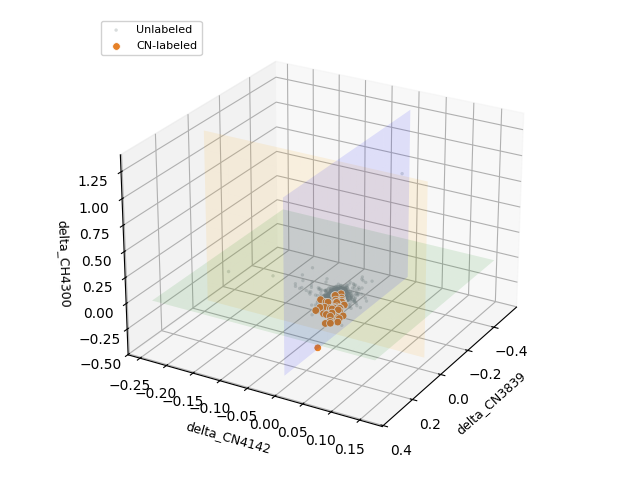

In [8]:
# 3D 散点图（delta特征）
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

plot_df = feature_df.copy()
cols_3d = ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'label']

plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=cols_3d).copy()

# 拆分标注/未标注样本
cn_df_plot = plot_df[plot_df['label'] == 1].copy()    # CN星（标注）
unl_df_plot = plot_df[plot_df['label'] == -1].copy()  # 未标注

# 未标注样本抽样
max_unlabeled_plot = 3000
if len(unl_df_plot) > max_unlabeled_plot:
    unl_df_plot = unl_df_plot.sample(max_unlabeled_plot, random_state=42)

plt.rcParams['font.size'] = 10  
fig = plt.figure()  
ax = fig.add_subplot(111, projection='3d')


x_min, x_max = plot_df['delta_CN3839'].min(), plot_df['delta_CN3839'].max()
y_min, y_max = plot_df['delta_CN4142'].min(), plot_df['delta_CN4142'].max()
z_min, z_max = plot_df['delta_CH4300'].min(), plot_df['delta_CH4300'].max()
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
y_grid2, z_grid2 = np.meshgrid(np.linspace(y_min, y_max, 10), np.linspace(z_min, z_max, 10))
x_grid3, z_grid3 = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(z_min, z_max, 10))

# 1. 水平面：z=0（垂直z轴）
ax.plot_surface(x_grid, y_grid, np.zeros_like(x_grid), 
                color='green', alpha=0.1, shade=False, zorder=0)
# 2. 垂直x轴平面：x=0
ax.plot_surface(np.zeros_like(y_grid2), y_grid2, z_grid2, 
                color='orange', alpha=0.1, shade=False, zorder=0)
# 3. 垂直y轴平面：y=0
ax.plot_surface(x_grid3, np.zeros_like(z_grid3), z_grid3, 
                color='blue', alpha=0.1, shade=False, zorder=0)

# 绘制散点图
# 未标注样本
ax.scatter(
    unl_df_plot['delta_CN3839'],
    unl_df_plot['delta_CN4142'],
    unl_df_plot['delta_CH4300'],
    c='#7f8c8d', s=6, alpha=0.3, label='Unlabeled',
    edgecolors='none', zorder=2
)

# 已知CN星
ax.scatter(
    cn_df_plot['delta_CN3839'],
    cn_df_plot['delta_CN4142'],
    cn_df_plot['delta_CH4300'],
    c='#e67e22', s=30, alpha=0.98, label='CN-labeled',
    edgecolors='white', linewidth=0.5, zorder=3
)

ax.set_xlabel('delta_CN3839', fontsize=9)
ax.set_ylabel('delta_CN4142', fontsize=9)
ax.set_zlabel('delta_CH4300', fontsize=9)

ax.view_init(elev=25, azim=30)

ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.decomposition import PCA

# 设置主成分数量（可手动指定或按方差比例自动确定）
# 方式一：固定数量
n_components = 10

# # 方式二：保留95%方差（若想使用请取消注释下面两行并注释上一行）
# pca = PCA(n_components=0.95)
# X_pca = pca.fit_transform(X_clean)
# n_components = X_pca.shape[1]

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_clean)

# 将主成分得分添加为新的特征列
for i in range(n_components):
    feature_df[f'pca_{i+1}'] = X_pca[:, i]

print(f"PCA 解释方差累计占比: {pca.explained_variance_ratio_.sum():.3f}")
print(f"已添加 {n_components} 个 PCA 特征列")

PCA 解释方差累计占比: 0.401
已添加 10 个 PCA 特征列


In [10]:
# 构建 PCA 特征列名列表（兼容未显式执行 PCA 参数单元）
if 'n_components' in globals():
    pca_cols = [f'pca_{i+1}' for i in range(n_components)]
else:
    pca_cols = [c for c in feature_df.columns if c.startswith('pca_')]

# KNN 中心差分特征（可解释）
if {'teff', 'knn_center_teff'}.issubset(feature_df.columns):
    feature_df['delta_teff_center'] = feature_df['teff'] - feature_df['knn_center_teff']
if {'logg', 'knn_center_logg'}.issubset(feature_df.columns):
    feature_df['delta_logg_center'] = feature_df['logg'] - feature_df['knn_center_logg']
if {'feh', 'knn_center_feh'}.issubset(feature_df.columns):
    feature_df['delta_feh_center'] = feature_df['feh'] - feature_df['knn_center_feh']
if {'mag_ps_g', 'knn_center_mag_ps_g'}.issubset(feature_df.columns):
    feature_df['delta_mag_center'] = feature_df['mag_ps_g'] - feature_df['knn_center_mag_ps_g']

# 选取用于分类的特征
base_feature_cols = [
    'teff', 'logg', 'feh',
    'mag_ps_g',
    'CN3839', 'CN4142', 'CH4300',
    'delta_CN3839', 'delta_CN4142', 'delta_CH4300',
    'nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300',
]
feature_cols = [c for c in (base_feature_cols + pca_cols) if c in feature_df.columns]

print(f'最终特征数: {len(feature_cols)}')
print(feature_cols)

最终特征数: 23
['teff', 'logg', 'feh', 'mag_ps_g', 'CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']


# XGboost Label iteration based on training

In [11]:
# 构建特征矩阵（收敛到更稳健的轻量特征子集）
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')
 
# 准备数据：限制 PCA 维度，避免小样本下高维特征噪声放大
max_pca_use = 4
pca_cols = [f'pca_{i}' for i in range(1, max_pca_use + 1) if f'pca_{i}' in feature_df.columns]

# 选取用于分类的特征（CN主导，CH作约束，减少冗余）
base_feature_cols = [
    'teff', 'logg', 'feh', 'mag_ps_g',
    'CN3839', 'CN4142', 'CH4300',
    'delta_CN3839', 'delta_CN4142', 'delta_CH4300',
    'knn_center_euclid', 'knn_center_dist_z'
 ]
feature_cols = [c for c in (base_feature_cols + pca_cols) if c in feature_df.columns]

# 准备数据
df_model = feature_df.copy()
df_model = df_model.dropna(subset=feature_cols + ['label'])

data_x = df_model[feature_cols].values
data_y = df_model['label'].map({1: 1, -1: 0}).values  # 1: CN star, 0: unlabeled

# 分离已标注正样本和未标注样本
pos_idx = np.where(data_y == 1)[0]
unl_idx = np.where(data_y == 0)[0]

# 构造“可靠负样本”种子池：CN指数整体偏低者优先
seed_score = np.full(len(df_model), np.nan, dtype=float)
if {'CN3839', 'CN4142'}.issubset(df_model.columns):
    seed_score = df_model['CN3839'].values + df_model['CN4142'].values

unl_seed = seed_score[unl_idx]
unl_seed_finite = unl_seed[np.isfinite(unl_seed)]
if len(unl_seed_finite) > 0:
    q25 = np.nanpercentile(unl_seed_finite, 25)
    reliable_neg_seed_idx = unl_idx[np.where(unl_seed <= q25)[0]]
else:
    reliable_neg_seed_idx = np.array([], dtype=int)

print(f'Use {len(feature_cols)} features: {feature_cols}')
print(f'Positive samples (CN stars): {len(pos_idx)}')
print(f'Unlabeled samples: {len(unl_idx)}')
print(f'Reliable negative seed pool: {len(reliable_neg_seed_idx)}')

Use 16 features: ['teff', 'logg', 'feh', 'mag_ps_g', 'CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'knn_center_euclid', 'knn_center_dist_z', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
Positive samples (CN stars): 73
Unlabeled samples: 33516
Reliable negative seed pool: 8379


In [12]:
# 初始负样本：优先从“可靠负样本种子池”采样，提升采样可靠性
np.random.seed(42)

neg_target = int(len(pos_idx) * 1.5)
if len(reliable_neg_seed_idx) >= neg_target:
    neg_idx_sampled = np.random.choice(reliable_neg_seed_idx, size=neg_target, replace=False)
else:
    need_more = neg_target - len(reliable_neg_seed_idx)
    remain_pool = np.setdiff1d(unl_idx, reliable_neg_seed_idx)
    extra = np.random.choice(remain_pool, size=min(need_more, len(remain_pool)), replace=False)
    neg_idx_sampled = np.concatenate([reliable_neg_seed_idx, extra])

train_idx = np.concatenate([pos_idx, neg_idx_sampled])
X_train = data_x[train_idx]
y_train = np.concatenate([np.ones(len(pos_idx)), np.zeros(len(neg_idx_sampled))])

# 划分训练集和验证集
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print(f"Training set: {X_tr.shape[0]} samples (positive: {int(sum(y_tr))})")
print(f"Validation set: {X_val.shape[0]} samples (positive: {int(sum(y_val))})")
print(f"Initial negatives sampled: {len(neg_idx_sampled)}")

Training set: 145 samples (positive: 58)
Validation set: 37 samples (positive: 15)
Initial negatives sampled: 109


In [13]:
# XGBoost 参数（更保守：抑制过拟合，提升概率排序稳定性）
xgb = XGBClassifier(
    n_estimators=320,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=4,
    gamma=0.2,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_alpha=0.3,
    reg_lambda=2.0,
    random_state=42,
    eval_metric='logloss'
 )

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 验证集评估
y_pred = xgb.predict(X_val)
y_prob = xgb.predict_proba(X_val)[:, 1]

print('Validation Classification Report:\n')
print(classification_report(y_val, y_pred, digits=4))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob):.4f}')
print(f'PR-AUC : {average_precision_score(y_val, y_prob):.4f}')

Validation Classification Report:

              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000        22
         1.0     1.0000    1.0000    1.0000        15

    accuracy                         1.0000        37
   macro avg     1.0000    1.0000    1.0000        37
weighted avg     1.0000    1.0000    1.0000        37

ROC-AUC: 1.0000
PR-AUC : 1.0000


In [14]:
# 自训练函数：每轮从最低概率中采样“可靠负样本”，避免随机负样本污染
def self_training(
    X_labeled, y_labeled, current_unl_idx,
    data_x, model,
    threshold=0.93, max_iter=4,
    neg_ratio=1.5, max_new_pos_per_iter=60, random_state=42
):
    """
    自训练迭代（可靠负样本版）
    - 正样本: 每轮取高概率未标注样本（限制单轮增量，防止漂移）
    - 负样本: 每轮从最低概率未标注样本中采样
    - 自适应兜底: 若固定阈值无样本，使用分位数阈值做极小增量更新
    """
    rng = np.random.default_rng(random_state)
    current_unl_idx = np.asarray(current_unl_idx, dtype=int).copy()

    for iteration in range(max_iter):
        if len(current_unl_idx) == 0:
            print(f'Iteration {iteration+1}: 无剩余未标注样本，停止迭代')
            break

        X_unlabeled_iter = data_x[current_unl_idx]
        prob_unl = model.predict_proba(X_unlabeled_iter)[:, 1]

        # 1) 高置信正样本（概率高）
        high_pos_local = np.where(prob_unl >= threshold)[0]
        if len(high_pos_local) == 0:
            q = float(np.nanpercentile(prob_unl, 99.8))
            adapt_thr = max(0.90, q)
            high_pos_local = np.where(prob_unl >= adapt_thr)[0]
            high_pos_local = high_pos_local[np.argsort(prob_unl[high_pos_local])[::-1]][:10]
            if len(high_pos_local) == 0:
                print(f'Iteration {iteration+1}: 未找到高置信正样本，停止迭代')
                break
            print(f'Iteration {iteration+1}: 使用自适应阈值 {adapt_thr:.4f} 选取 {len(high_pos_local)} 个样本')

        # 控制单轮新增上限，减少标签漂移
        high_pos_local = high_pos_local[np.argsort(prob_unl[high_pos_local])[::-1]]
        high_pos_local = high_pos_local[:max_new_pos_per_iter]
        new_pos_idx = current_unl_idx[high_pos_local]

        X_new_pos = data_x[new_pos_idx]
        y_new_pos = np.ones(len(new_pos_idx), dtype=float)

        X_labeled = np.vstack([X_labeled, X_new_pos])
        y_labeled = np.concatenate([y_labeled, y_new_pos])

        # 2) 从未标注池移除新正样本
        keep_mask = np.ones(len(current_unl_idx), dtype=bool)
        keep_mask[high_pos_local] = False
        remain_idx = current_unl_idx[keep_mask]
        remain_prob = prob_unl[keep_mask]

        if len(remain_idx) == 0:
            current_unl_idx = remain_idx
            print(f'Iteration {iteration+1}: 已无剩余未标注样本')
            break

        # 3) 可靠负样本：从最低概率区域采样
        n_pos = int(np.sum(y_labeled))
        n_neg = min(int(np.ceil(n_pos * neg_ratio)), len(remain_idx))

        low_order = np.argsort(remain_prob)
        low_pool_size = min(max(3 * n_neg, n_neg), len(low_order))
        low_pool = low_order[:low_pool_size]

        if len(low_pool) > n_neg:
            chosen_local = rng.choice(low_pool, size=n_neg, replace=False)
        else:
            chosen_local = low_pool

        new_neg_idx = remain_idx[chosen_local]
        X_new_neg = data_x[new_neg_idx]
        y_new_neg = np.zeros(len(new_neg_idx), dtype=float)

        # 4) 重训
        X_balanced = np.vstack([X_labeled, X_new_neg])
        y_balanced = np.concatenate([y_labeled, y_new_neg])
        model.fit(X_balanced, y_balanced, verbose=False)

        current_unl_idx = remain_idx
        print(
            f"Iteration {iteration+1}: +pos={len(new_pos_idx)}, neg={len(new_neg_idx)}, "
            f"total_pos={int(np.sum(y_labeled))}, remaining_unl={len(current_unl_idx)}, "
            f"new_pos_prob_med={np.median(prob_unl[high_pos_local]):.4f}"
        )

    return model, X_labeled, y_labeled, current_unl_idx

# 执行自训练
initial_unl_idx = np.setdiff1d(unl_idx, neg_idx_sampled)
xgb_st, X_labeled_final, y_labeled_final, remaining_unl_idx = self_training(
    X_labeled=X_train,
    y_labeled=y_train,
    current_unl_idx=initial_unl_idx,
    data_x=data_x,
    model=xgb,
    threshold=0.93,
    max_iter=4,
    neg_ratio=1.5,
    max_new_pos_per_iter=60,
    random_state=42
)

# 当前剩余未标注特征矩阵
X_unlabeled = data_x[remaining_unl_idx]

Iteration 1: +pos=60, neg=200, total_pos=133, remaining_unl=33347, new_pos_prob_med=0.9432
Iteration 2: +pos=60, neg=290, total_pos=193, remaining_unl=33287, new_pos_prob_med=0.9798
Iteration 3: +pos=60, neg=380, total_pos=253, remaining_unl=33227, new_pos_prob_med=0.9867
Iteration 4: +pos=60, neg=470, total_pos=313, remaining_unl=33167, new_pos_prob_med=0.9893


In [15]:
# 对剩余未标注数据预测概率
prob_all_unl = xgb_st.predict_proba(X_unlabeled)[:, 1]
print('Unlabeled prob quantiles:', np.nanpercentile(prob_all_unl, [90, 95, 99, 99.5, 99.9]))

# 初步候选（概率门槛）
candidate_threshold = 0.93
high_conf_mask = prob_all_unl >= candidate_threshold
candidate_idx = remaining_unl_idx[high_conf_mask]
candidate_prob = prob_all_unl[high_conf_mask]

# 若阈值过严，使用 TopN 兜底
min_candidates = 120
if len(candidate_idx) < min_candidates:
    topn = min(min_candidates, len(prob_all_unl))
    order_all = np.argsort(prob_all_unl)[::-1][:topn]
    candidate_idx = remaining_unl_idx[order_all]
    candidate_prob = prob_all_unl[order_all]
    print(f'Fallback to Top-{topn} candidates for inspection.')

# 物理约束：CN增强 + CH不偏离已知分布
aux_cols = ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']
known_mask = feature_df['label'].values == 1
known_aux = feature_df.loc[known_mask, aux_cols].replace([np.inf, -np.inf], np.nan).dropna()

if len(known_aux) > 0:
    cn1_floor = np.nanpercentile(known_aux['delta_CN3839'], 35)
    cn2_floor = np.nanpercentile(known_aux['delta_CN4142'], 35)
    ch_med = np.nanmedian(known_aux['delta_CH4300'])
    ch_mad = np.nanmedian(np.abs(known_aux['delta_CH4300'] - ch_med)) + 1e-6
else:
    cn1_floor, cn2_floor, ch_med, ch_mad = 0.0, 0.0, 0.0, 0.02

cand_aux = feature_df.iloc[candidate_idx][aux_cols].copy()
cand_aux['CN_prob'] = candidate_prob
cand_aux = cand_aux.replace([np.inf, -np.inf], np.nan).dropna()

phys_mask = (
    (cand_aux['delta_CN3839'] >= cn1_floor) &
    (cand_aux['delta_CN4142'] >= cn2_floor) &
    (np.abs(cand_aux['delta_CH4300'] - ch_med) <= 2.8 * ch_mad)
 )
cand_aux = cand_aux.loc[phys_mask].copy()

# 综合分数：概率 + CN双指数增强
cand_aux['score'] = (
    0.65 * cand_aux['CN_prob'] +
    0.20 * cand_aux['delta_CN3839'].rank(pct=True) +
    0.15 * cand_aux['delta_CN4142'].rank(pct=True)
 )

# 限制最终候选数量，便于人工复核
top_k_final = 300
cand_aux = cand_aux.sort_values('score', ascending=False).head(top_k_final)

candidate_idx_sorted = cand_aux.index.values.astype(int)
candidate_prob_sorted = cand_aux['CN_prob'].values.astype(float)

# 构建候选 DataFrame
cand_cols = [
    'ra', 'dec', 'teff', 'logg', 'feh', 'filepath',
    'neighbor_indices', 'rv', 'masked_cluster_id'
 ]
cand_cols = [c for c in cand_cols if c in stars_clean.columns]
candidates_df = stars_clean.iloc[candidate_idx_sorted][cand_cols].copy()
candidates_df['CN_prob'] = candidate_prob_sorted
candidates_df['final_score'] = cand_aux['score'].values

print(f"Physics-filtered candidates: {len(candidates_df)} (top_k={top_k_final}, base threshold={candidate_threshold})")
candidates_df.head(10)

# 保存候选列表
candidates_df.to_csv('cn_candidates_xgboost_tuned.csv', index=False)
print('Candidate list saved to cn_candidates_xgboost_tuned.csv')

Unlabeled prob quantiles: [0.97662205 0.98577327 0.98958001 0.99023473 0.99023473]
Physics-filtered candidates: 215 (top_k=300, base threshold=0.93)
Candidate list saved to cn_candidates_xgboost_tuned.csv


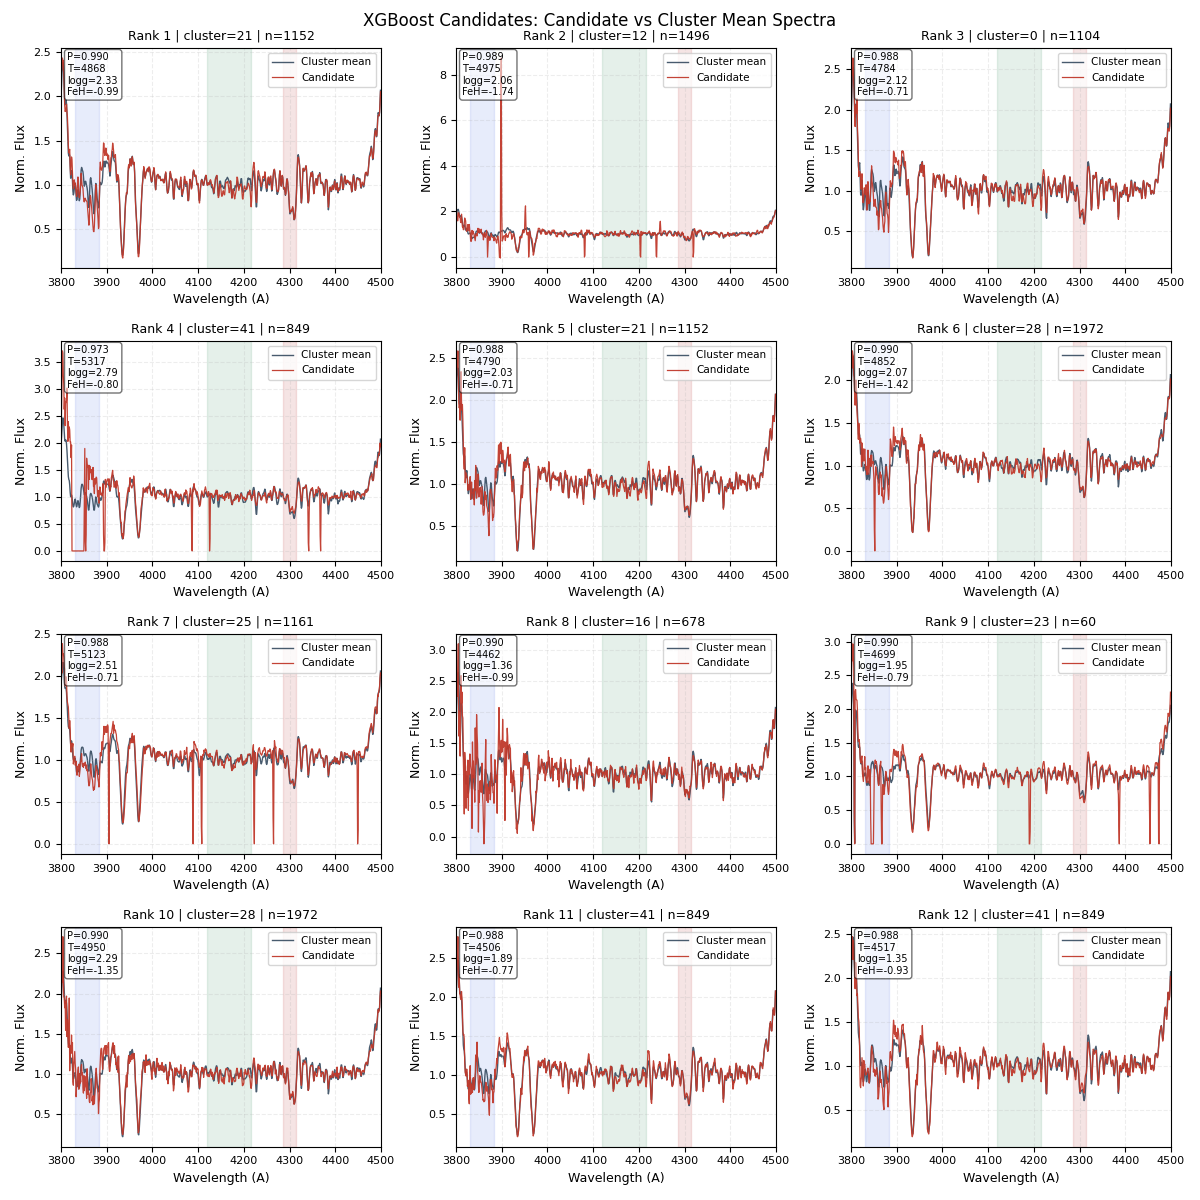

In [18]:
# XGBoost筛选结果可视化：候选光谱 vs 所在簇平均光谱
top = candidates_df.head(12).copy()

if len(top) == 0:
    print('当前无可视化候选，请先运行候选筛选单元。')
else:
    # 通过 filepath 回溯到 stars_clean 索引，直接使用 X_clean 绘图，避免重复读盘
    filepath_to_idx = {fp: i for i, fp in enumerate(stars_clean['filepath'].values)}

    fig, axes = plt.subplots(4, 3, figsize=(12, 12))
    axes = axes.flatten()

    for i, (_, row) in enumerate(top.iterrows()):
        ax = axes[i]
        prob = row['CN_prob']
        filepath = row['filepath']

        if filepath not in filepath_to_idx:
            ax.text(0.5, 0.5, 'filepath not matched', ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_title(f'Rank {i+1} (match failed)', fontsize=10)
            ax.axis('off')
            continue

        idx = filepath_to_idx[filepath]
        cand_flux = np.asarray(X_clean[idx], dtype=float)
        cid = int(stars_clean.iloc[idx]['masked_cluster_id'])
        cluster_idx = np.where(stars_clean['masked_cluster_id'].values == cid)[0]
        cluster_mean = np.nanmedian(X_clean[cluster_idx], axis=0)

        # 分子带背景
        ax.axvspan(3830, 3883, alpha=0.12, color='royalblue', zorder=0)
        ax.axvspan(4120, 4216, alpha=0.12, color='seagreen', zorder=0)
        ax.axvspan(4285, 4315, alpha=0.12, color='firebrick', zorder=0)

        # 平均光谱 vs 候选光谱
        ax.plot(common_wave, cluster_mean, color='#34495e', linewidth=1.0, alpha=0.9, zorder=1, label='Cluster mean')
        ax.plot(common_wave, cand_flux,color='#c0392b', linewidth=0.9, alpha=0.95, zorder=2, label='Candidate')

        # 参数文本
        text_parts = [f'P={prob:.3f}']
        if 'teff' in row and pd.notna(row['teff']):
            text_parts.append(f'T={row["teff"]:.0f}')
        if 'logg' in row and pd.notna(row['logg']):
            text_parts.append(f'logg={row["logg"]:.2f}')
        if 'feh' in row and pd.notna(row['feh']):
            text_parts.append(f'FeH={row["feh"]:.2f}')
        textstr = '\n'.join(text_parts)
        ax.text(
            0.02, 0.98, textstr, transform=ax.transAxes, fontsize=7, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.55), zorder=3
        )

        ax.set_xlim(3800, 4500)
        ax.set_xlabel('Wavelength (A)', fontsize=9)
        ax.set_ylabel('Norm. Flux', fontsize=9)
        ax.set_title(f'Rank {i+1} | cluster={cid} | n={len(cluster_idx)}', fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(True, alpha=0.22, linestyle='--')
        ax.legend(loc='upper right', fontsize=7.5)

    for j in range(len(top), len(axes)):
        axes[j].axis('off')

    fig.suptitle('XGBoost Candidates: Candidate vs Cluster Mean Spectra', fontsize=12, y=0.99)
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

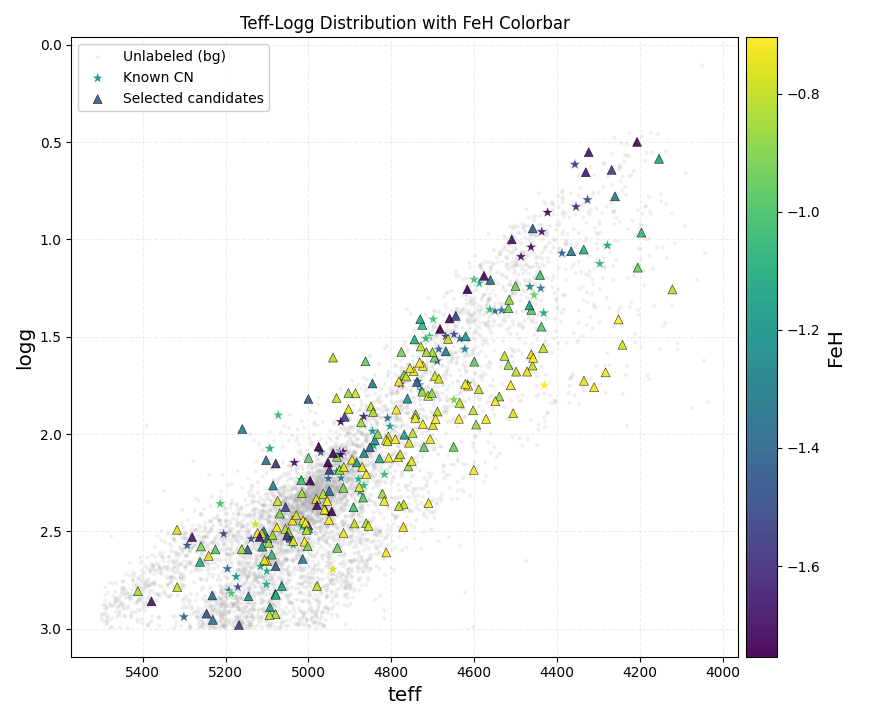

Known CN: 73, Candidates: 215, Unlabeled(bg shown): 6000


In [17]:
# 三参数星体分布（单图）：x=teff, y=logg, color=feh
need_cols = ['teff', 'logg', 'feh', 'label']
if not set(need_cols).issubset(stars_clean.columns):
    print(f'缺少必要列: {need_cols}')
else:
    plot_df = stars_clean[need_cols].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    # 候选标记
    cand_set = set(np.asarray(candidate_idx_sorted, dtype=int).tolist()) if 'candidate_idx_sorted' in globals() else set()
    plot_df['is_candidate'] = plot_df.index.to_series().isin(cand_set).astype(int)

    # 背景未标注样本（抽样）
    unl_bg = plot_df[(plot_df['label'] == -1) & (plot_df['is_candidate'] == 0)]
    max_unlabeled_plot = 6000
    if len(unl_bg) > max_unlabeled_plot:
        unl_bg = unl_bg.sample(max_unlabeled_plot, random_state=42)

    # 颜色范围根据已知CN+候选确定，减少极端值影响
    focus_df = plot_df[(plot_df['label'] == 1) | (plot_df['is_candidate'] == 1)]
    if len(focus_df) == 0:
        focus_df = plot_df.copy()
    vmin = np.nanpercentile(focus_df['feh'], 2)
    vmax = np.nanpercentile(focus_df['feh'], 98)
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin >= vmax):
        vmin = np.nanmin(plot_df['feh'])
        vmax = np.nanmax(plot_df['feh'])

    fig, ax = plt.subplots(figsize=(8.8, 7.2))

    # 背景：未标注（灰）
    ax.scatter(
        unl_bg['teff'], unl_bg['logg'],
        s=8, c='#b0b0b0', alpha=0.20, edgecolors='none', label='Unlabeled (bg)'
    )

    # 前景：已知CN + 候选，颜色映射FeH
    known_df = plot_df[plot_df['label'] == 1]
    cand_df = plot_df[plot_df['is_candidate'] == 1]

    sc1 = ax.scatter(
        known_df['teff'], known_df['logg'],
        c=known_df['feh'], cmap='viridis', vmin=vmin, vmax=vmax,
        s=80, marker='*', edgecolors='white', linewidth=0.45, alpha=0.95, label='Known CN'
    )
    ax.scatter(
        cand_df['teff'], cand_df['logg'],
        c=cand_df['feh'], cmap='viridis', vmin=vmin, vmax=vmax,
        s=42, marker='^', edgecolors='black', linewidth=0.35, alpha=0.92, label='Selected candidates'
    )

    cbar = plt.colorbar(sc1, ax=ax, pad=0.01)
    cbar.set_label('FeH')

    ax.set_xlabel('teff')
    ax.set_ylabel('logg')
    ax.set_title('Teff-Logg Distribution with FeH Colorbar')
    ax.grid(True, linestyle='--', alpha=0.22)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.legend(loc='best', framealpha=0.9)

    plt.tight_layout()
    plt.show()

    print(f'Known CN: {len(known_df)}, Candidates: {len(cand_df)}, Unlabeled(bg shown): {len(unl_bg)}')